In [1]:
## IMPORTS ##
####################################

#scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# general
import numpy as np
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys

# imagery
# import tifffile as tiff
# from PIL import Image
# import rasterio

# xarray
import xarray as xr

# geo
import geopandas as gpd



In [2]:
## ============================================================= ##
## COMPILE DATASET WITH LABEL INFORMATION FROM DUNMIRE AND RINES ##
## ============================================================= ##

# load Dunmire information
ds_base    = xr.open_dataset("/home/jupyter/repos/lake-vision/sandbox/all_lakes_2019.nc")
gdf_labels = gpd.read_file ("/home/jupyter/repos/lake-vision/sandbox/labels_2019_volumes.geojson")

# keep only CW lakes, sort by ID, and restrict to May 1–Sep 30
ds_cw = (
    ds_base
    .sel(ids=ds_base.ids.str.contains("CW"))
    .sortby("ids")
    .sel(time=slice("2019-05-01", "2019-09-30"))
)

# attach final_label from the GeoJSON (indexed by new_id → ds_cw.ids)
gdf2   = gdf_labels.set_index("new_id")
flabel = gdf2.reindex(ds_cw.ids.values)["final_label"].values
ds_labeled = ds_cw.assign(final_label=("ids", flabel))

# forward- and back-fill all time-varying variables so there are no NaNs
time_vars    = [v for v, da in ds_labeled.data_vars.items() if "time" in da.dims]
df_filled    = (
    ds_labeled[time_vars]
      .to_dataframe()
      .groupby(level="ids")
      .ffill()
      .bfill()
)
ds_timefilled = df_filled.to_xarray()
ds_filled     = xr.merge([ds_timefilled, ds_labeled.drop_vars(time_vars)])

# compute the dates of maximum water for S2 and LS and add to dataset
date_max_S2 = ds_filled.S2_water.idxmax(dim="time")
date_max_LS = ds_filled.LS_water.idxmax(dim="time")
ds_with_max = ds_filled.assign(
    date_maxwater_S2 = ("ids", date_max_S2.values),
    date_maxwater_LS = ("ids", date_max_LS.values),
)

# read-in Rines information and attach ND_HF_O by positional match (e.g., Dunmire CW2019_1524 == Rines 2019cw_1)
df_csv   = pd.read_csv("/home/jupyter/repos/lake-vision/sandbox/labels_2019cw.csv")
nd_hf_o  = df_csv["ND_HF_O"].values
ds_final = ds_with_max.assign(ND_HF_O=("ids", nd_hf_o))

# rename label variables
ds_final = ds_final.rename({
    "ND_HF_O":       "label_Rines",
    "final_label":   "label_Dunmire_raw"
})

# make 0 and 3 the same label for Dunmire (for ease of comparison with Rines, which does not split out "refreeze" from "buried" classes)
ds_final = ds_final.assign(
    label_Dunmire = xr.where(
        (ds_final.label_Dunmire_raw == 0) | (ds_final.label_Dunmire_raw == 3),
        0,
        ds_final.label_Dunmire_raw
    )
)

# attach the lakenum strings as a coordinate along the ids dimension
ds_final = ds_final.assign_coords(
    lakenum=("ids", df_csv["lakenum"].values)
)

# print ds_final to verify
ds_final



<xarray.Dataset> Size: 11MB
Dimensions:            (ids: 1000, time: 153)
Coordinates:
  * ids                (ids) object 8kB 'CW2019_1524' ... 'CW2019_2523'
  * time               (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
    lakenum            (ids) object 8kB '2019cw_1' '2019cw_2' ... '2019cw_1000'
Data variables: (12/14)
    S1_image_id        (ids, time) object 1MB '' ... 'S1A_IW_GRDH_1SDH_201909...
    S1_code            (ids, time) object 1MB '' '25-A-2' ... '25-B-2' '127-A-2'
    HV_lake            (ids, time) float64 1MB -15.7 -15.7 ... -18.5 -18.64
    HV_out             (ids, time) float64 1MB -14.74 -14.74 ... -18.0 -18.27
    S2_water           (ids, time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S2_zenith          (ids, time) float64 1MB 53.52 53.52 53.52 ... 71.16 71.16
    ...                 ...
    t2m                (ids, time) float64 1MB 270.8 271.9 270.0 ... 267.7 268.2
    label_Dunmire_raw  (ids) int32 4kB 0 2 2 3 2 2 2 2 2 2 ... 2 2 2 2 2 1 2 2 2
    date_maxwater_S2   (ids) datetime64[ns] 8kB 2019-08-10 ... 2019-06-13
    date_maxwater_LS   (ids) datetime64[ns] 8kB 2019-08-11 ... 2019-06-08
    label_Rines        (ids) int64 8kB 2 2 2 0 2 2 2 2 2 2 ... 2 2 2 2 2 1 2 2 2
    label_Dunmire      (ids) int32 4kB 0 2 2 0 2 2 2 2 2 2 ... 2 2 2 2 2 1 2 2 2

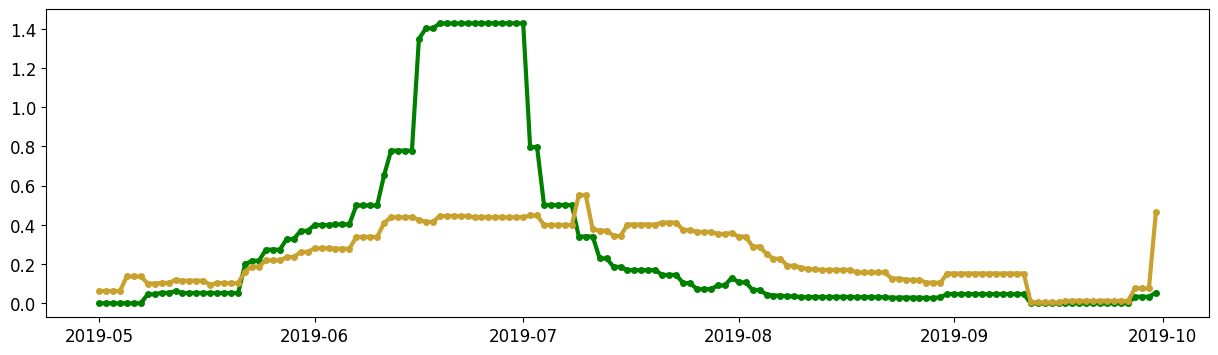

In [3]:


plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 18,    # title
    'axes.labelsize': 16,    # x/y labels
    'xtick.labelsize': 12,   # x‐tick labels
    'ytick.labelsize': 12,   # y‐tick labels
    'legend.fontsize': 12,   # legend text
    'legend.title_fontsize': 14
})

# lakes and their mustard‐adjusted colors
lake_ids = [825, 820]
colors = {
    825: 'green',
    820: '#C9A12F',    # mustard yellow
}

# one label per lake (in the same order as lake_ids)
laketype = [
    "hydrofracture", "lateral flow"
]

fig, ax = plt.subplots(figsize=(15, 4))

area_km_826 = []
area_km_821 = []
for idx_lake, lid in enumerate(lake_ids):
    vals = ds_final.S2_water[lid].values
    mask = ~np.isnan(vals)
    t = ds_final.time.values[mask]
    v = vals[mask]
    if lid==825:
        n_water_pix = 1.5e4 * v
        area = n_water_pix * 100
        area_km = area/1e6
        area_km_826.append(area_km)
        ax.plot(t, area_km, 'o-', 
                color=colors[lid],
                linewidth=3, 
                markersize=4,
                label=laketype[idx_lake])
    elif lid==820:
        n_water_pix = 0.75e4 * v
        area = n_water_pix * 100
        area_km = area/1e6
        area_km_821.append(area_km)
        ax.plot(t, area_km, 'o-', 
                color=colors[lid],
                linewidth=3, 
                markersize=4,
                label=laketype[idx_lake])




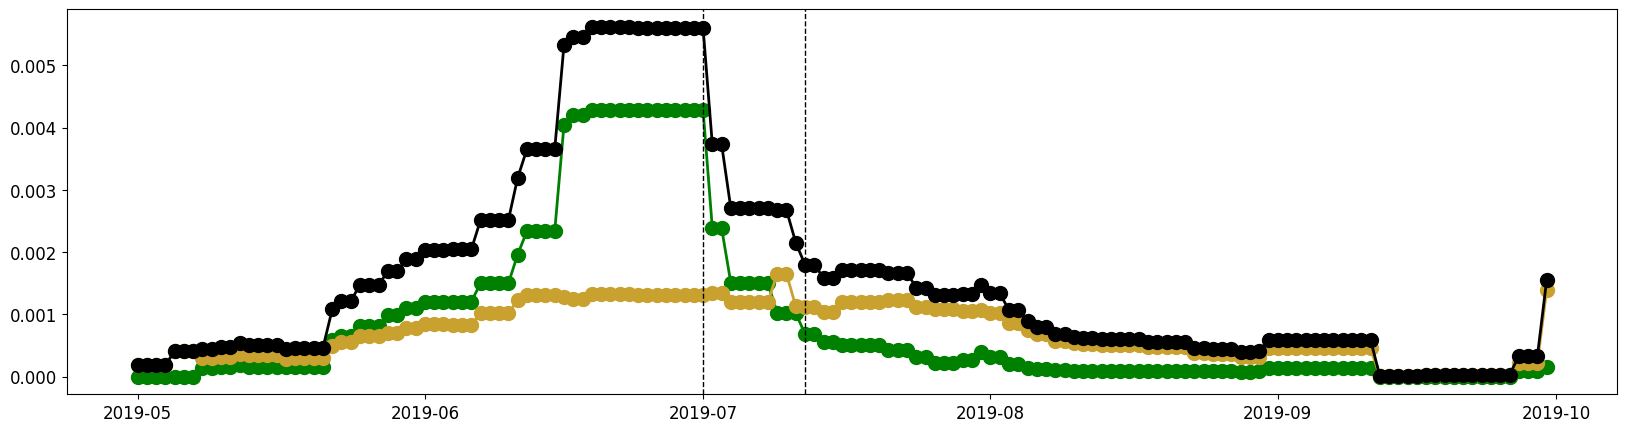

In [4]:
vol826 = area_km_826[0]*3e-3
vol821 = area_km_821[0]*3e-3
voltot = vol826 + vol821

plt.figure(figsize=(20,5))

plt.plot(t, vol826, 'o-', markersize=10, color='green', linewidth=2)
plt.plot(t, vol821, 'o-', markersize=10, color='#C9A12F', linewidth=2)
plt.plot(t, voltot, 'o-', markersize=10, color='black', linewidth=2)

plt.axvline(pd.to_datetime('2019-07-01'), color='black', linestyle='--', linewidth=1)
plt.axvline(pd.to_datetime('2019-07-12'), color='black', linestyle='--', linewidth=1)



In [5]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# 1) Window your data
start = pd.Timestamp('2019-07-01')
end   = pd.Timestamp('2019-08-26')
mask  = (t >= start) & (t <= end)

t2      = pd.to_datetime(t[mask])
vol8262 = vol826[mask]
vol8212 = vol821[mask]
voltot2 = voltot[mask]

# 2) Build x = days since start
x = (t2 - start) / pd.Timedelta(days=1)

# 3) Exponential‐decay model
def exp_decay(x, A, k, C):
    return A * np.exp(-k * x) + C

# 4) Bounds and smart initial guesses
bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])

p0_826 = [vol8262.max()-vol8262.min(), 0.1, vol8262.min()]
p0_821 = [vol8212.max()-vol8212.min(), 0.1, vol8212.min()]
p0_tot = [voltot2.max()-voltot2.min(), 0.1, voltot2.min()]

# 5) Fit with increased maxfev
params_826, cov_826 = curve_fit(
    exp_decay, x, vol8262, p0=p0_826, bounds=bounds, maxfev=10000
)
params_821, cov_821 = curve_fit(
    exp_decay, x, vol8212, p0=p0_821, bounds=bounds, maxfev=10000
)
params_tot, cov_tot = curve_fit(
    exp_decay, x, voltot2, p0=p0_tot, bounds=bounds, maxfev=10000
)

# 6) Inspect results
print("params_826 (A, k, C):", params_826)
print("params_821 (A, k, C):", params_821)
print("params_tot (A, k, C):", params_tot)



params_826 (A, k, C): [0.0032286  0.16389413 0.0001762 ]
params_821 (A, k, C): [1.51459257e-03 1.96247532e-02 7.02061588e-12]
params_tot (A, k, C): [0.00357024 0.06852391 0.00053961]


In [6]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# 1) Window your data
start = pd.Timestamp('2019-07-01')
end   = pd.Timestamp('2019-08-26')
mask  = (t >= start) & (t <= end)

t2      = pd.to_datetime(t[mask])
vol8262 = vol826[mask]
vol8212 = vol821[mask]
voltot2 = voltot[mask]

# 2) Build x = days since start
x = (t2 - start) / pd.Timedelta(days=1)

# 3) Exponential‐decay model
def exp_decay(x, A, k, C):
    return A * np.exp(-k * x) + C

# 4) Bounds and smart initial guesses
bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])
p0_826 = [vol8262.max() - vol8262.min(), 0.1, vol8262.min()]
p0_821 = [vol8212.max() - vol8212.min(), 0.1, vol8212.min()]
p0_tot = [voltot2.max() - voltot2.min(), 0.1, voltot2.min()]

# 5) Build weights so first 3 points are 5× more important
weights = np.ones_like(x, dtype=float)
weights[:2] = 10.0
# curve_fit wants sigma where weight = 1/sigma² → sigma = 1/√weight
sigma_tot = 1.0 / np.sqrt(weights)
sigma = 1

# 6) Fit with sigma (relative weights) and increased maxfev
params_826, cov_826 = curve_fit(
    exp_decay, x, vol8262,
    p0=p0_826, bounds=bounds,
    sigma=sigma, absolute_sigma=False,
    maxfev=10000
)
params_821, cov_821 = curve_fit(
    exp_decay, x, vol8212,
    p0=p0_821, bounds=bounds,
    sigma=sigma, absolute_sigma=False,
    maxfev=10000
)
params_tot, cov_tot = curve_fit(
    exp_decay, x, voltot2,
    p0=p0_tot, bounds=bounds,
    sigma=sigma_tot, absolute_sigma=False,
    maxfev=10000
)

# 7) Inspect results
print("Weighted params_826 (A, k, C):", params_826)
print("Weighted params_821 (A, k, C):", params_821)
print("Weighted params_tot (A, k, C):", params_tot)


Weighted params_826 (A, k, C): [0.0032286  0.16389413 0.0001762 ]
Weighted params_821 (A, k, C): [1.51459257e-03 1.96247532e-02 7.02061588e-12]
Weighted params_tot (A, k, C): [0.0040558  0.12283082 0.00084996]


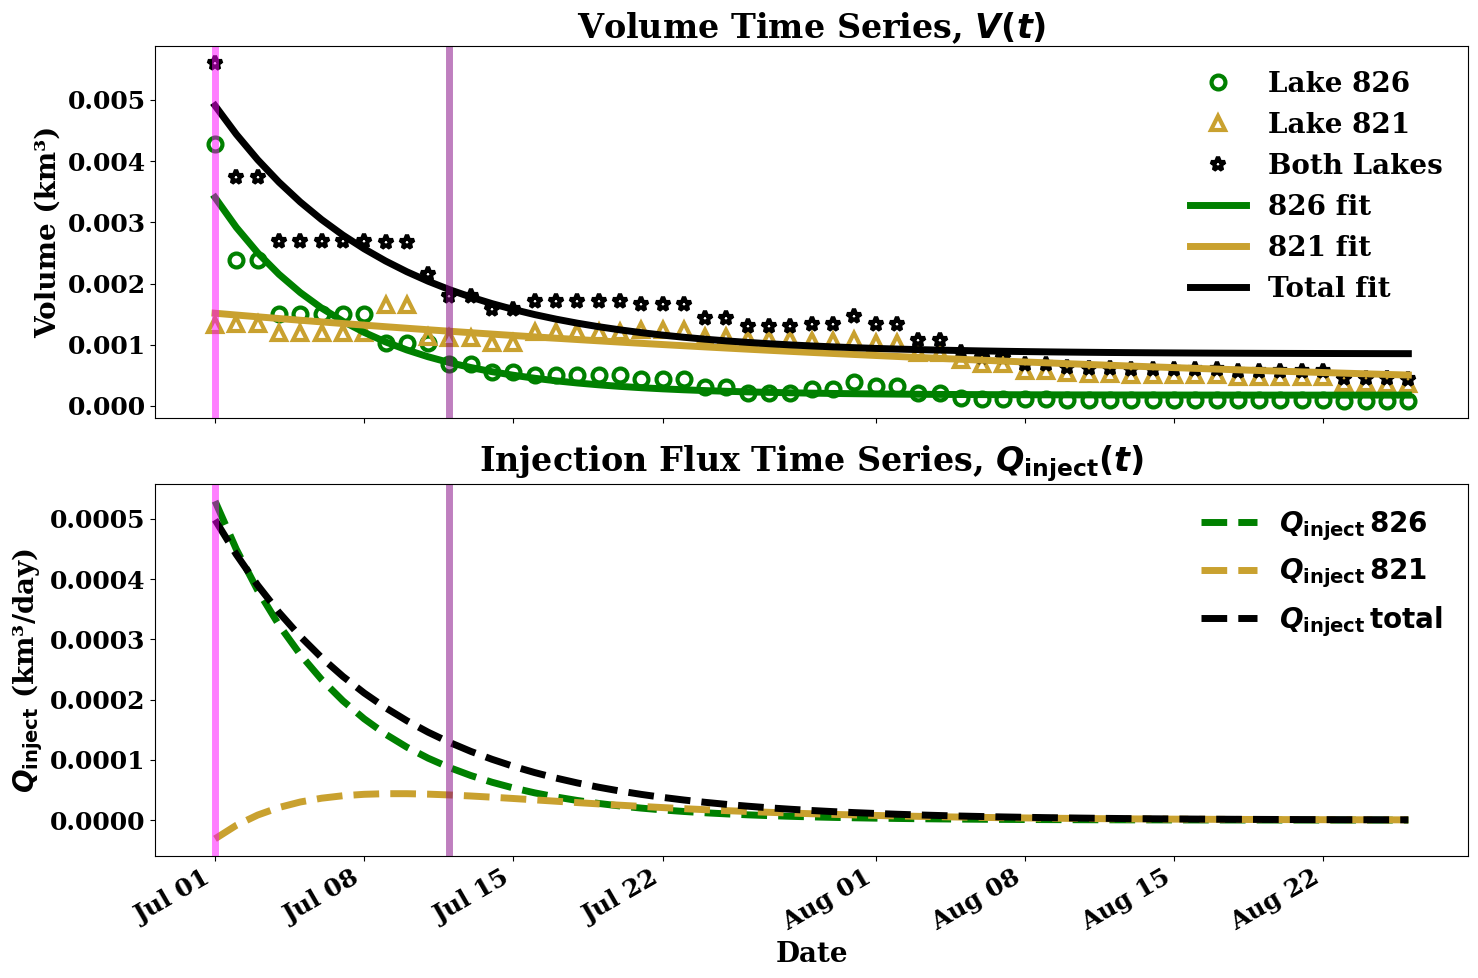

<Figure size 640x480 with 0 Axes>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ── ASSUMPTION: you already have defined in your namespace ──
#   t           : array‐like of datetime (or convertible) for full period
#   vol826, vol821, voltot : ndarrays of same length as t
#   params_826 = (A826, k826, C826)
#   params_821 = (A821, k821, C821)
#   params_tot = (Atot, ktot, Ctot)

# 1) Window the data between 2019-07-01 and 2019-08-26
start = pd.Timestamp('2019-07-01')
end   = pd.Timestamp('2019-08-26')
mask  = (t >= start) & (t <= end)

t2      = pd.to_datetime(t[mask])
vol8262 = vol826[mask]
vol8212 = vol821[mask]
voltot2 = voltot[mask]

# 2) Compute "days since start" as floats
x = (t2 - start) / pd.Timedelta(days=1)  # e.g. [0., 1., 2., ...]

# 3) Unpack your exponential‐decay parameters
A826, k826, C826 = params_826
A821, k821, C821 = params_821
Atot, ktot, Ctot = params_tot

# 4) Evaluate the exponential fits: V(x) = A e^(–k x) + C
fit_826 = A826 * np.exp(-k826 * x) + C826
fit_821 = A821 * np.exp(-k821 * x) + C821
fit_tot = Atot  * np.exp(-ktot * x) + Ctot

# 5) Compute the analytical flux: Q = dV/dt = -A k e^(–k x)
d826 = -A826 * k826 * np.exp(-k826 * x)
d821 = -A821 * k821 * np.exp(-k821 * x)
dtot = -Atot  * ktot  * np.exp(-ktot  * x)
d821 = dtot - d826

# 6) Paper‐quality styling
plt.rcParams.update({
    'font.family':      'serif',
    'font.weight':      'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize':   24,
    'axes.labelsize':   20,
    'xtick.labelsize':  18,
    'ytick.labelsize':  18,
    'legend.fontsize':  20
})

# 7) Create two‐panel figure
fig, (ax_vol, ax_flux) = plt.subplots(
    2, 1, sharex=True, figsize=(15, 10),
    gridspec_kw={'height_ratios': [1, 1]}
)

# ── Upper panel: Volume + exponential fits ──
# data points
ax_vol.plot(t2, vol8262, linestyle='None', marker='o',
            markersize=10, markeredgewidth=3,
            markerfacecolor='none', markeredgecolor='green',
            label='Lake 826')
ax_vol.plot(t2, vol8212, linestyle='None', marker='^',
            markersize=10, markeredgewidth=3,
            markerfacecolor='none', markeredgecolor='#C9A12F',
            label='Lake 821')
ax_vol.plot(t2, voltot2, linestyle='None', marker='*',
            markersize=10, markeredgewidth=3,
            markerfacecolor='none', markeredgecolor='black',
            label='Both Lakes')

# fits
ax_vol.plot(t2, fit_826, '-', color='green',   linewidth=5, label='826 fit')
ax_vol.plot(t2, fit_821, '-', color='#C9A12F', linewidth=5, label='821 fit')
ax_vol.plot(t2, fit_tot, '-', color='black',   linewidth=5, label='Total fit')

# key‐date verticals
for dt, col in zip(['2019-07-01','2019-07-12'], ['magenta','purple']):
    ax_vol.axvline(pd.to_datetime(dt), color=col,
                   linestyle='-', linewidth=5, alpha=0.5)

ax_vol.set_ylabel('Volume (km³)', fontweight='bold')
ax_vol.legend(loc='upper right', frameon=False)
ax_vol.set_title('Volume Time Series, $V(t)$')

# ── Lower panel: Injection flux Q_inject ──
ax_flux.plot(t2, -d826, '--', color='green',   linewidth=5,
             label=r'$Q_{\mathrm{inject}}\,826$')
ax_flux.plot(t2, -d821, '--', color='#C9A12F', linewidth=5,
             label=r'$Q_{\mathrm{inject}}\,821$')
ax_flux.plot(t2, -dtot, '--', color='black',   linewidth=5,
             label=r'$Q_{\mathrm{inject}}\,\mathrm{total}$')

for dt, col in zip(['2019-07-01','2019-07-12'], ['magenta','purple']):
    ax_flux.axvline(pd.to_datetime(dt), color=col,
                    linestyle='-', linewidth=5, alpha=0.5)

ax_flux.set_xlabel('Date', fontweight='bold')
ax_flux.set_ylabel(r'$Q_{\mathrm{inject}}$ (km³/day)', fontweight='bold')
ax_flux.legend(loc='upper right', frameon=False)
ax_flux.set_title('Injection Flux Time Series, $Q_{\mathrm{inject}}(t)$')

# create a formatter that drops the year
date_fmt = mdates.DateFormatter('%b %d')  # e.g. "Jul 01"

# apply to both subplots (they share x)
ax_vol.xaxis.set_major_formatter(date_fmt)
ax_flux.xaxis.set_major_formatter(date_fmt)

# rotate if you like
for ax in (ax_vol, ax_flux):
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


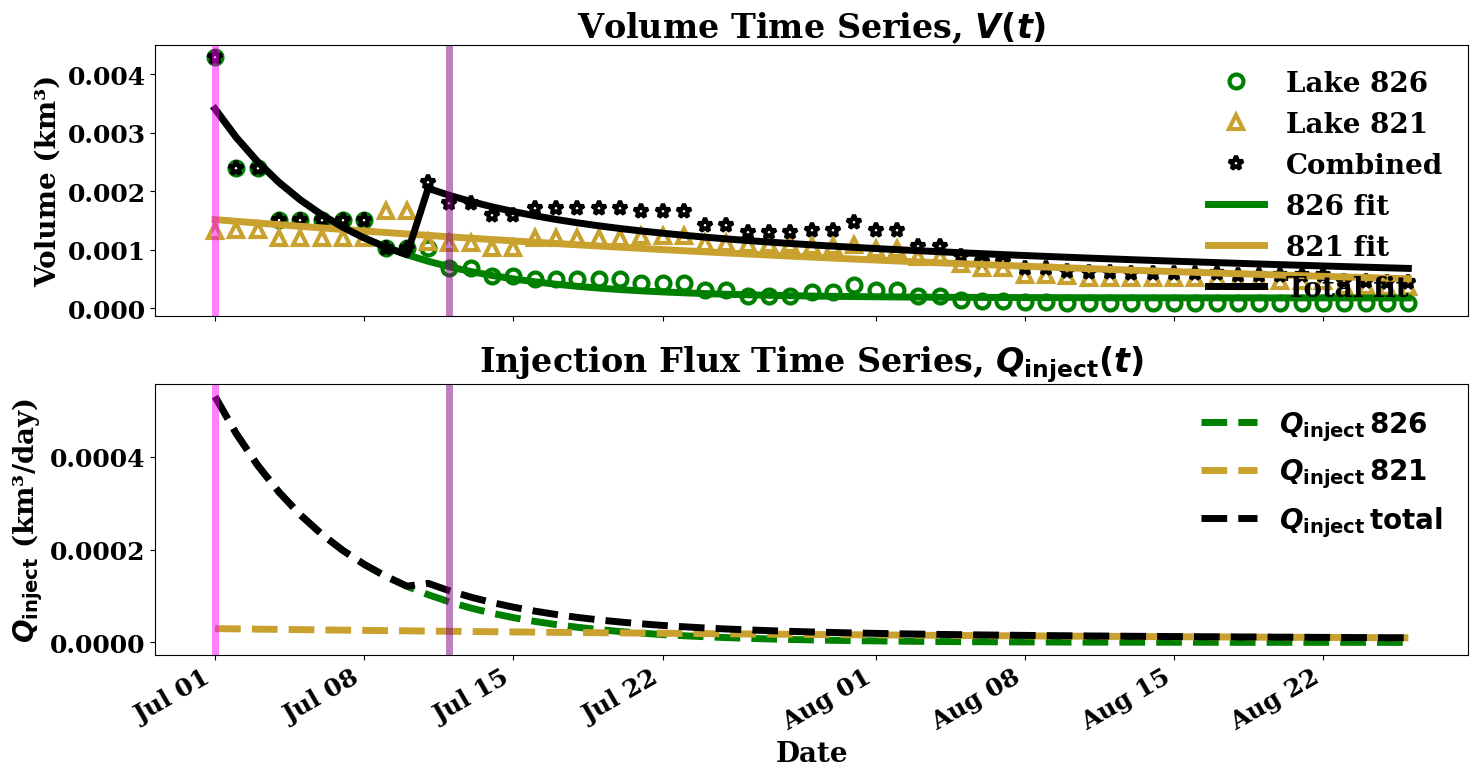

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

# ── ASSUMPTION: t, vol826, vol821 are defined; start/end windowing as before ──

start = pd.Timestamp('2019-07-01')
end   = pd.Timestamp('2019-08-26')
mask  = (t >= start) & (t <= end)

t2      = pd.to_datetime(t[mask])
vol8262 = vol826[mask]
vol8212 = vol821[mask]
# we’ll ignore the old voltot2 and rebuild it piecewise

# x = days since start
x = (t2 - start) / pd.Timedelta(days=1)

# fit decay parameters (if not already done)
def exp_decay(x, A, k, C):
    return A * np.exp(-k * x) + C

# … your curve_fit calls to get params_826 and params_821 …

A826, k826, C826 = params_826
A821, k821, C821 = params_821

# evaluate fits
fit_826 = A826 * np.exp(-k826 * x) + C826
fit_821 = A821 * np.exp(-k821 * x) + C821

# analytical derivatives
d826 = -A826 * k826 * np.exp(-k826 * x)
d821 = -A821 * k821 * np.exp(-k821 * x)

# ── HERE: piecewise combine at pivot x ≤ 9 days (July 10) ──
pivot_day = 9.0   # July 10 is 9 days after July 1

# measured total:
voltot2_pw = np.where(x <= pivot_day,
                      vol8262,
                      vol8262 + vol8212)

# fit total:
fit_tot_pw = np.where(x <= pivot_day,
                      fit_826,
                      fit_826 + fit_821)

# flux total:
dtot_pw = np.where(x <= pivot_day,
                   d826,
                   d826 + d821)

# ── Plot exactly as before, but use the *_pw arrays for total ──

plt.rcParams.update({
    'font.family':      'serif',
    'font.weight':      'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize':   24,
    'axes.labelsize':   20,
    'xtick.labelsize':  18,
    'ytick.labelsize':  18,
    'legend.fontsize':  20
})

fig, (ax_vol, ax_flux) = plt.subplots(
    2,1, sharex=True, figsize=(15,8),
    gridspec_kw={'height_ratios':[1,1]}
)

# Volume panel
ax_vol.plot(t2, vol8262, linestyle='None', marker='o',
            markersize=10, markeredgewidth=3,
            markerfacecolor='none', markeredgecolor='green',
            label='Lake 826')
ax_vol.plot(t2, vol8212, linestyle='None', marker='^',
            markersize=10, markeredgewidth=3,
            markerfacecolor='none', markeredgecolor='#C9A12F',
            label='Lake 821')
ax_vol.plot(t2, voltot2_pw, linestyle='None', marker='*',
            markersize=10, markeredgewidth=3,
            markerfacecolor='none', markeredgecolor='black',
            label='Combined')

ax_vol.plot(t2, fit_826, '-', color='green',   linewidth=5, label='826 fit')
ax_vol.plot(t2, fit_821, '-', color='#C9A12F', linewidth=5, label='821 fit')
ax_vol.plot(t2, fit_tot_pw, '-', color='black',   linewidth=5, label='Total fit')

for dt, col in zip(['2019-07-01','2019-07-12'], ['magenta','purple']):
    ax_vol.axvline(pd.to_datetime(dt), color=col,
                   linestyle='-', linewidth=5, alpha=0.5)

ax_vol.set_ylabel('Volume (km³)', fontweight='bold')
ax_vol.legend(loc='upper right', frameon=False)
ax_vol.set_title('Volume Time Series, $V(t)$')

# Flux panel
ax_flux.plot(t2, -d826, '--', color='green',   linewidth=5,
             label=r'$Q_{\mathrm{inject}}\,826$')
ax_flux.plot(t2, -d821, '--', color='#C9A12F', linewidth=5,
             label=r'$Q_{\mathrm{inject}}\,821$')
ax_flux.plot(t2, -dtot_pw, '--', color='black',   linewidth=5,
             label=r'$Q_{\mathrm{inject}}\,\mathrm{total}$')

for dt, col in zip(['2019-07-01','2019-07-12'], ['magenta','purple']):
    ax_flux.axvline(pd.to_datetime(dt), color=col,
                    linestyle='-', linewidth=5, alpha=0.5)

ax_flux.set_xlabel('Date', fontweight='bold')
ax_flux.set_ylabel(r'$Q_{\mathrm{inject}}$ (km³/day)', fontweight='bold')
ax_flux.legend(loc='upper right', frameon=False)
ax_flux.set_title('Injection Flux Time Series, $Q_{\mathrm{inject}}(t)$')

date_fmt = mdates.DateFormatter('%b %d')
ax_vol.xaxis.set_major_formatter(date_fmt)
ax_flux.xaxis.set_major_formatter(date_fmt)
for ax in (ax_vol, ax_flux):
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

# ── ASSUMPTION: t, vol826, vol821 are defined; start/end windowing as before ──

start = pd.Timestamp('2019-07-01')
end   = pd.Timestamp('2019-08-26')
mask  = (t >= start) & (t <= end)

t2      = pd.to_datetime(t[mask])
vol8262 = vol826[mask]
vol8212 = vol821[mask]
# we’ll ignore the old voltot2 and rebuild it piecewise

# x = days since start
x = (t2 - start) / pd.Timedelta(days=1)

# fit decay parameters (if not already done)
def exp_decay(x, A, k, C):
    return A * np.exp(-k * x) + C

# … your curve_fit calls to get params_826 and params_821 …

A826, k826, C826 = params_826
A821, k821, C821 = params_821

# evaluate fits
fit_826 = A826 * np.exp(-k826 * x) + C826
fit_821 = A821 * np.exp(-k821 * x) + C821

# analytical derivatives
d826 = -A826 * k826 * np.exp(-k826 * x)
d821 = -A821 * k821 * np.exp(-k821 * x)

# ── HERE: piecewise combine at pivot x ≤ 9 days (July 10) ──
pivot_day = 9.0   # July 10 is 9 days after July 1

# measured total:
voltot2_pw = np.where(x <= pivot_day,
                      vol8262,
                      vol8262 + vol8212)

# fit total:
fit_tot_pw = np.where(x <= pivot_day,
                      fit_826,
                      fit_826 + fit_821)

# flux total:
dtot_pw = np.where(x <= pivot_day,
                   d826,
                   d826 + d821)

# ── Plot exactly as before, but use the *_pw arrays for total ──

plt.rcParams.update({
    'font.family':      'serif',
    'font.weight':      'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize':   24,
    'axes.labelsize':   20,
    'xtick.labelsize':  18,
    'ytick.labelsize':  18,
    'legend.fontsize':  20
})

fig, (ax_vol, ax_flux) = plt.subplots(
    2,1, sharex=True, figsize=(15,8),
    gridspec_kw={'height_ratios':[1,1]}
)

# Volume panel
ax_vol.plot(t2, vol8262, linestyle='None', marker='o',
            markersize=10, markeredgewidth=3,
            markerfacecolor='none', markeredgecolor='green',
            label='Lake 826')
ax_vol.plot(t2, vol8212, linestyle='None', marker='^',
            markersize=10, markeredgewidth=3,
            markerfacecolor='none', markeredgecolor='#C9A12F',
            label='Lake 821')
ax_vol.plot(t2, voltot2_pw, linestyle='None', marker='*',
            markersize=10, markeredgewidth=3,
            markerfacecolor='none', markeredgecolor='black',
            label='Combined')

ax_vol.plot(t2, fit_826, '-', color='green',   linewidth=5, label='826 fit')
ax_vol.plot(t2, fit_821, '-', color='#C9A12F', linewidth=5, label='821 fit')
ax_vol.plot(t2, fit_tot_pw, '-', color='black',   linewidth=5, label='Total fit')

for dt, col in zip(['2019-07-01','2019-07-12'], ['magenta','purple']):
    ax_vol.axvline(pd.to_datetime(dt), color=col,
                   linestyle='-', linewidth=5, alpha=0.5)

ax_vol.set_ylabel('Volume (km³)', fontweight='bold')
ax_vol.legend(loc='upper right', frameon=False)
ax_vol.set_title('Volume Time Series, $V(t)$')

# Flux panel
ax_flux.plot(t2, -d826, '--', color='green',   linewidth=5,
             label=r'$Q_{\mathrm{inject}}\,826$')
ax_flux.plot(t2, -d821, '--', color='#C9A12F', linewidth=5,
             label=r'$Q_{\mathrm{inject}}\,821$')
ax_flux.plot(t2, -dtot_pw, '--', color='black',   linewidth=5,
             label=r'$Q_{\mathrm{inject}}\,\mathrm{total}$')

for dt, col in zip(['2019-07-01','2019-07-12'], ['magenta','purple']):
    ax_flux.axvline(pd.to_datetime(dt), color=col,
                    linestyle='-', linewidth=5, alpha=0.5)

ax_flux.set_xlabel('Date', fontweight='bold')
ax_flux.set_ylabel(r'$Q_{\mathrm{inject}}$ (km³/day)', fontweight='bold')
ax_flux.legend(loc='upper right', frameon=False)
ax_flux.set_title('Injection Flux Time Series, $Q_{\mathrm{inject}}(t)$')

date_fmt = mdates.DateFormatter('%b %d')
ax_vol.xaxis.set_major_formatter(date_fmt)
ax_flux.xaxis.set_major_formatter(date_fmt)
for ax in (ax_vol, ax_flux):
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()



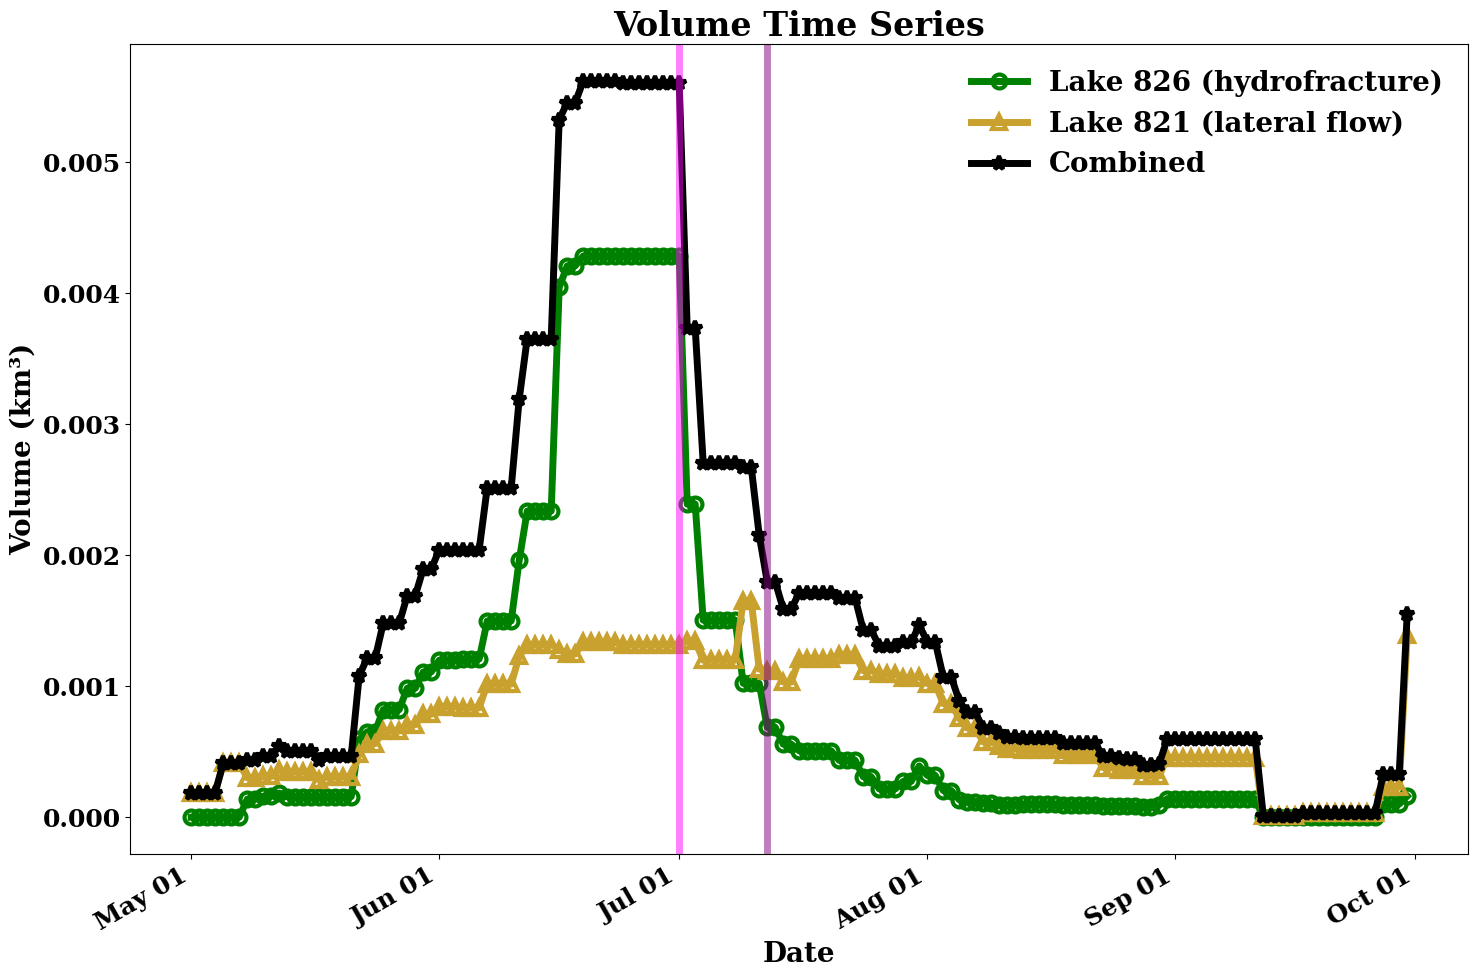

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1) Paper-quality styling
plt.rcParams.update({
    'font.family':      'serif',
    'font.weight':      'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize':   24,
    'axes.labelsize':   20,
    'xtick.labelsize':  18,
    'ytick.labelsize':  18,
    'legend.fontsize':  20
})

# 2) Create figure and axis
fig, ax = plt.subplots(figsize=(15, 10))

# 3) Plot each series with empty markers and thick outlines
ax.plot(
    t, vol826,  # ensure vol826 = area_km_826[0]*3e-3
    linestyle='-',
    marker='o',
    markersize=10,
    markeredgewidth=3,
    markerfacecolor='none',
    markeredgecolor='green',
    color='green',
    linewidth=5,
    label='Lake 826 (hydrofracture)'
)
ax.plot(
    t, vol821,  # ensure vol821 = area_km_821[0]*3e-3
    linestyle='-',
    marker='^',
    markersize=10,
    markeredgewidth=3,
    markerfacecolor='none',
    markeredgecolor='#C9A12F',
    color='#C9A12F',
    linewidth=5,
    label='Lake 821 (lateral flow)'
)
ax.plot(
    t, vol826 + vol821,  # combined volume
    linestyle='-',
    marker='*',
    markersize=10,
    markeredgewidth=3,
    markerfacecolor='none',
    markeredgecolor='black',
    color='black',
    linewidth=5,
    label='Combined'
)


# 4) Labels, title, legend
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Volume (km³)', fontweight='bold')
ax.set_title('Volume Time Series', fontweight='bold')
ax.legend(loc='upper right', frameon=False)

# 5) Date formatter for x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# add in vertical lines at important dates
for dt, col in zip(['2019-07-01','2019-07-12'], ['magenta','purple']):
    ax.axvline(pd.to_datetime(dt), color=col,
                    linestyle='-', linewidth=5, alpha=0.5)

plt.tight_layout()
plt.show()


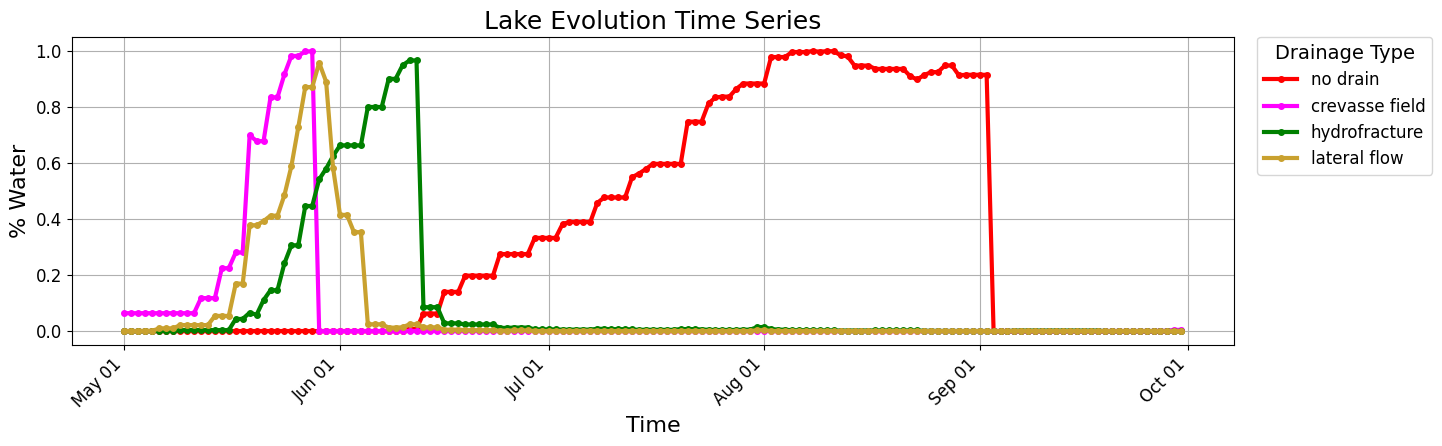

In [5]:


plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 18,    # title
    'axes.labelsize': 16,    # x/y labels
    'xtick.labelsize': 12,   # x‐tick labels
    'ytick.labelsize': 12,   # y‐tick labels
    'legend.fontsize': 12,   # legend text
    'legend.title_fontsize': 14
})

# lakes and their mustard‐adjusted colors
lake_ids = [40, 520, 365, 332]
colors = {
    40:  'red',
    520: 'magenta',
    365: 'green',
    332: '#C9A12F',    # mustard yellow
}

# one label per lake (in the same order as lake_ids)
laketype = [
    "no drain", 
    "crevasse field", 
    "hydrofracture", "lateral flow"
]

fig, ax = plt.subplots(figsize=(15, 4))

for idx_lake, lid in enumerate(lake_ids):
    vals = ds_final.S2_water[lid].values
    mask = ~np.isnan(vals)
    t = ds_final.time.values[mask]
    v = vals[mask]
    
    ax.plot(t, v, 'o-', 
            color=colors[lid],
            linewidth=3, 
            markersize=4,
            label=laketype[idx_lake])

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Time")
ax.set_ylabel("% Water")
ax.set_title("Lake Evolution Time Series")
ax.grid(True)

# place legend outside upper right
ax.legend(
    title="Drainage Type",
    loc='upper left',              # anchor the legend’s upper-left corner...
    bbox_to_anchor=(1.02, 1),      # … at x=1.02 (just outside), y=1 (top of axes)
    borderaxespad=0                # no padding between axes and legend
)
